# 1.Tools概述

Tools 用于扩展大语言模型（LLM）的能力，使其能够与外部系统、API 或自定义函数交互，从而完成仅靠文本生成无法实现的任务（如搜索、计算、数据库查询等）。

特点：  
1、增强 LLM 的功能：让 LLM 突破纯文本生成的限制，执行实际操作（如调用搜索引擎、查询数据库、运行代码等）  
2、支持智能决策：在Agent 工作流中，LLM 根据用户输入动态选择最合适的 Tool 完成任务。  
3、模块化设计：每个 Tool 专注一个功能，便于复用和组合（例如：搜索工具 + 计算工具 + 天气查询工具）


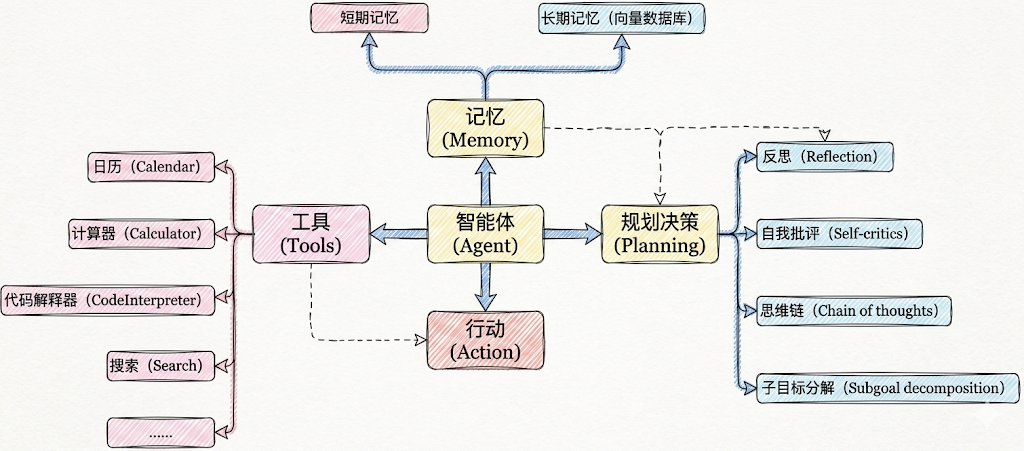

Tool 通常包含如下几个要素：  
**name** ：工具的名称  
**description** ：工具的功能描述  
该工具输入的JSON模式  
要调用的函数  
**return_direct** ：是否应将工具结果直接返回给用户（仅对Agent相关）

# 2.工具调用的方式
LangChain中，tools实际上是指明确定义了输入和输出的可调用函数，  
因此工具调用（tool calling）也被称为函数调用（function calling），function calling也包括MCP

## 调用方式1：直接调用
for test

In [2]:
from langchain_core.tools import tool
@tool
def get_weather(city: str) -> str:
    """
    获取指定城市的天气信息
    参数:
    city: 城市名称，如"北京"、"上海"
    返回:
    天气信息字符串
    """
    # 你的实现
    return city + "晴天，温度 15°C"

In [3]:
# 使用 .invoke() 方法
result = get_weather.invoke({"city": "北京"})
print(result)

北京晴天，温度 15°C


## 调用方式2：绑定到模型（主流）

In [4]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
DASHSCOPE_BASE_URL = os.getenv("DASHSCOPE_BASE_URL")
model = init_chat_model(
    model="deepseek-v4-pro",
    model_provider="openai",
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_BASE_URL
)

In [ ]:
from langchain_core.tools import tool

# 定义工具
@tool
def get_weather(city: str) -> str:
    """获取指定城市的天气"""
    # 你的实现
    return "晴天，温度 15°C"

# 绑定工具
model_with_tools = model.bind_tools([get_weather])

# AI 可以决定是否调用工具
response = model_with_tools.invoke("北京天气如何？")
# response = model_with_tools.invoke("2 + 3 = ？")

# 检查 AI 是否要调用工具
if response.tool_calls:
    print("AI 想调用工具：", response.tool_calls)   
else:
    print("AI 直接回答：", response.content)

AI 想调用工具： [{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_405fa27ebd984f4baa1c855d', 'type': 'tool_call'}]


# 3.工具调用的整体流程
<span style="color:red;">**大模型可以根据上下文决定何时调用工具以及传递哪些参数。**</span>
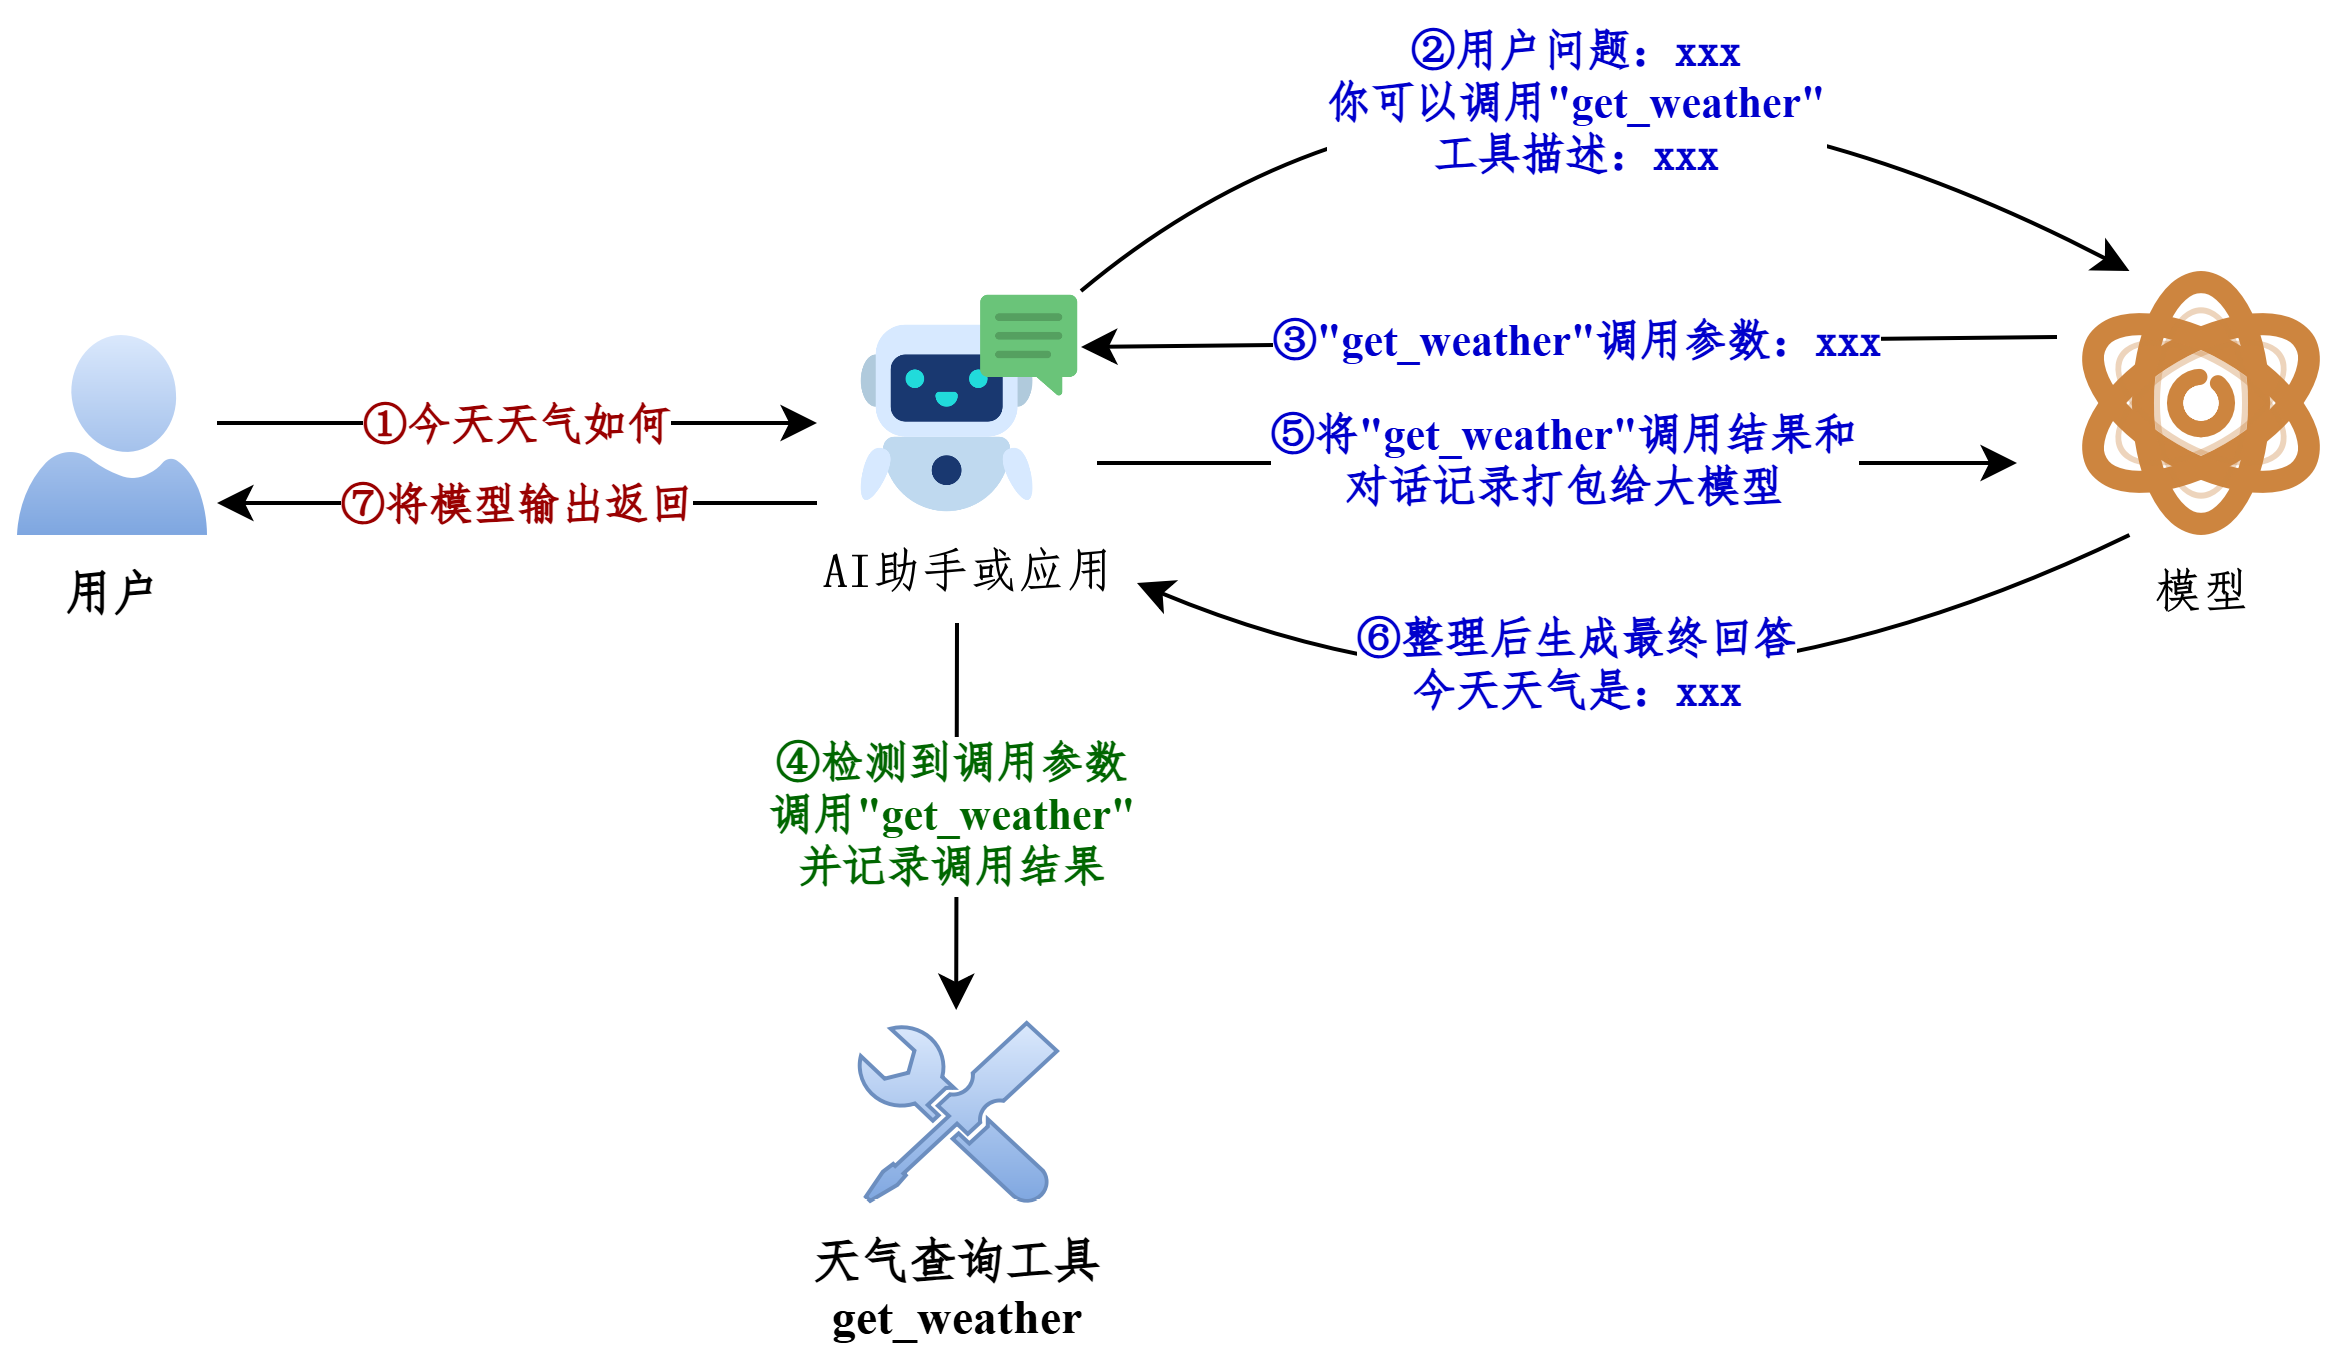

tools调用的流程：  
步骤1：将name、description 和 JSON模式作为上下文提供给LLM  
步骤2：LLM会根据提示词推断出需要调用哪些工具，并提供具体的调用参数信息  
步骤3：用户需要根据返回的工具调用信息，自行触发相关工具的回调

# 4.从Messages流转看工具使用

先初始化模型：

In [6]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
DASHSCOPE_BASE_URL = os.getenv("DASHSCOPE_BASE_URL")
model = init_chat_model(
    model="deepseek-v4-pro",
    model_provider="openai",
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_BASE_URL
)

参考1：不使用@tool修饰

In [7]:
from langchain.messages import HumanMessage, ToolMessage
def get_weather(city: str):
    """获取天气的工具"""
    return f"{city}天气晴朗"
# 将模型和工具绑定
model_with_tools = model.bind_tools([get_weather])
messages = [
    HumanMessage("今天北京天气如何")
]
# 模型生成调用工具请求
response = model_with_tools.invoke(messages)
# 添加AIMessage
messages.append(response)
tool_calls = response.tool_calls
for tool_call in tool_calls:
    if tool_call["name"] == "get_weather":
        # 拼接出ToolMessage实例
        tool_response = ToolMessage(
            content=get_weather(**tool_call["args"]),
            tool_call_id=tool_call["id"],
            name=tool_call["name"]
        )
        messages.append(tool_response)

print("=====================> messages <=====================")
for msg in messages:
    msg.pretty_print()
print("=====================> messages <=====================")
final_response = model_with_tools.invoke(messages)
print(f"final_response: \n{final_response}")

=====================> messages <=====================
================================ Human Message =================================

今天北京天气如何
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_3265a6477e3744ebb0ef969c)
 Call ID: call_3265a6477e3744ebb0ef969c
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京天气晴朗
=====================> messages <=====================
final_response: 
content='今天北京的天气**晴朗**，是个好天气！适合出门活动，不过也别忘记做好防晒哦～ ☀️' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 335, 'total_tokens': 383, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 21, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-pro', 'sy

参考2：使用@tool修饰

In [ ]:
from langchain.messages import HumanMessage, ToolMessage
@tool
def get_weather(city: str):
    """获取天气的工具"""
    return f"{city}天气晴朗~"
# 将模型和工具绑定
model_with_tools = model.bind_tools([get_weather])
messages = [
    HumanMessage("今天北京天气如何")
]
# 模型生成调用工具请求
response = model_with_tools.invoke(messages)
# 添加AIMessage
messages.append(response)
tool_calls = response.tool_calls
for tool_call in tool_calls:
    if tool_call["name"] == "get_weather":
        # 大模型和Agent的主要区别在于：大模型不会主动调用工具，所以这时候需要我们主动让工具别调用
        # 返回的是ToolMessage类型消息，添加到消息列表中
        tool_response = get_weather.invoke(tool_call)
        print(type(tool_response))
        messages.append(tool_response)

print("=====================> messages <=====================")
for msg in messages:
    msg.pretty_print()
print("=====================> messages <=====================")
final_response = model_with_tools.invoke(messages)
print(f"final_response: \n{final_response}")

<class 'langchain_core.messages.tool.ToolMessage'>
=====================> messages <=====================
================================ Human Message =================================

今天北京天气如何
================================== Ai Message ==================================

好的，我来帮您查询今天北京的天气。
Tool Calls:
  get_weather (call_517b47a4ef2742bf818d1b5e)
 Call ID: call_517b47a4ef2742bf818d1b5e
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京天气晴朗~
=====================> messages <=====================
final_response: 
content='今天北京的天气是**晴朗**的 ☀️，非常适合出门活动哦！' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 346, 'total_tokens': 394, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 29, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model

<span style="color:red;">说明：</span>  
被@tool 修饰的函数可以调用invoke 接收模型返回的入参信息执行函数，  
并返回ToolMessage 实例，我们不再需要手动拼接ToolMessage 。

# 5.工具的定义方式1：不使用@tool的方式
## 1）举例：不是有装饰器

In [10]:
# 1.初始化模型
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
DASHSCOPE_BASE_URL = os.getenv("DASHSCOPE_BASE_URL")
model = init_chat_model(
    model="deepseek-v4-pro",
    model_provider="openai",
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_BASE_URL
)
# 2.定义函数
def get_weather(city : str):
    return f"{city}天气晴朗~"

# 3.将函数绑定模型
model_with_tools = model.bind_tools([get_weather])

# 4.调用模型
res = model_with_tools.invoke("上海的天气怎么样？")
rprint(res)

AIMessage(
    content='好的，让我为您查询上海当前的天气情况',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 82,
            'prompt_tokens': 271,
            'total_tokens': 353,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 27,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'deepseek-v4-pro',
        'system_fingerprint': None,
        'id': 'chatcmpl-3ade896c-0a44-9a59-a8fc-b7b7ebc831f9',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019fdac7-69f8-7fc1-91df-f024b87f0b97-0',
    tool_calls=[
        {
            'name': 'get_weather',
            'args': {'city': '上海'},
            'id': 'call_231ea247c32348d992e11e02',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 271,
        'output_tokens': 82,
        'total_tokens': 353,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 27}
    }
)

# 6.工具描述的各部分详解
## 1）了解convert_to_openai_tool
执行model.bind_tools([get_weather]) ，底层最终会调用convert_to_openai_tool 生成工具描述。所
以我们可以直接调用后者查看解析后的工具描述。

In [13]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(city: str):
    return f"{city}天气晴朗"

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

结果字段说明：
- (1) **type**：定义当前数据节点必须是什么数据类型。常见类型有 string, number, integer, boolean,object, array, null。object即是json对象。
- (2) **properties**：用于定义JSON 对象（Object）中可以包含哪些属性（键），以及每个属性对应的值类型和说明。
- (3) **required**：当 type为 "object"时使用，是一个数组，列出了对象中必须存在的属性名。

<span style="color:red;">**问题：为什么不使用@tool装饰器修饰的函数，也可以理解为工具呢？**</span>  
查看convert_to_openai_tool 底层源码：

In [ ]:
# elif isinstance(function, langchain_core.tools.base.BaseTool):
#     oai_function = cast("dict", _format_tool_to_openai_function(function))
# elif callable(function):
#     oai_function = cast(
#         "dict", _convert_python_function_to_openai_function(function)
#     )

相当于加了@tool修饰的函数走上面的分支，  
没有加@tool修饰的函数走下面的分支，  
后者会基于函数定义和docstring生成pydantic模式的描述，然后转换为规范的tool_schema。

## 2）description说明
- **convert_to_openai_tool** 会从docstring(文档字符串) 加载工具的描述信息，上面的案例中，
- **docstring** 为空，所以抽取的description 为空。

docstring，文档字符串，使用三个双引号表示开始和结束。

In [14]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(city: str):
    """
    天气查询工具
    """
    return f"{city}天气晴朗"
rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '天气查询工具',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

## 3）参数说明

convert_to_openai_tool 会从docstring 加载参数说明，这里的docstring 必须遵循Google 风格。
- Google 风格docstring 说明：https://google.github.io/styleguide/pyguide.html
- Google 风格docstring 示例：https://www.sphinx-doc.org/en/master/usage/extensions/example_google.html
- Python docstring 通用约定：https://peps.python.org/pep-0257/  
基础用法不必完整阅读规范，只需要按照下面的示例仿写即可。

In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}天气晴朗"

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '天气查询工具',
        'parameters': {
            'properties': {'city': {'description': '城市名称', 'type': 'string'}},
            'required': ['city'],
            'type': 'object'
        }
    }
}

使用 Args: 、Returns: 、Raises: 等关键字，这种方式可读性强。  
Agent通过工具的这些注释来理解工具的用途和调用时机，  
因此清晰、准确的文档字符串是工具能被正确调用的前提。

## 4）参数类型说明
参数类型来源于函数的类型注解。

In [16]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(city):
    """
    天气查询工具
    """
    return f"{city}天气晴朗"
rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '天气查询工具',
        'parameters': {'properties': {'city': {}}, 'required': ['city'], 'type': 'object'}
    }
}

**删除了参数类型注解，则工具描述中不包含参数类型说明**  
**注意：如果docstring中包含参数说明，则对应的参数必须有类型注解，否则报错**

In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(city):
    """
    天气查询工具
    
    Args:
        city: 城市名称
    """
    print("天气晴朗")
rprint(convert_to_openai_tool(get_weather))

会报错：  
ValueError: Arg city in docstring not found in function signature.

## 5）参数默认值说明
如果参数没有默认值，则会包含在required对应的列表中。  
反之，则参数的描述信息会包含default 字段，并且不会出现在required列表中。
### 举例1：有默认值

In [18]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(city: str="北京"):
    """
    天气查询工具
    
    Args:
        city: 城市名称
    """
    return f"{city}天气晴朗"
rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '天气查询工具',
        'parameters': {
            'properties': {'city': {'default': '北京', 'description': '城市名称', 'type': 'string'}},
            'type': 'object'
        }
    }
}

**目前只有一个参数，并且有默认值，所以required字段被移除了。**

### 举例2：无默认值

In [19]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint
def get_weather(dt: str, city: str="北京"):
    """
    天气查询工具

    Args:
        dt: 日期
        city: 城市名称
    """
    return f"{city}天气晴朗"
rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '天气查询工具',
        'parameters': {
            'properties': {
                'dt': {'description': '日期', 'type': 'string'},
                'city': {'default': '北京', 'description': '城市名称', 'type': 'string'}
            },
            'required': ['dt'],
            'type': 'object'
        }
    }
}

# 7.工具的定义方式2：使用@tool装饰器(推荐)

使用@tool 装饰器修饰，可以自动将普通 Python 函数转化为智能体可调用的工具。  
此方式最直接，代码量极少，非常适合快速验证想法或创建参数简单的工具。

## 自定义工具描述：description
### 情况1：仅提供docstring信息
在bind_tools()调用时，先将函数封装为BaseTool 类型的对象，再传递给convert_to_openai_tool 函
数，生成工具的描述。

In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain.tools import tool

@tool
def get_weather(city: str):
    return f"{city}天气晴朗"

print(convert_to_openai_tool(get_weather))

@tool 会从docstring 生成描述信息，同样要求遵循Google docstring 规范。如果没有docstring
则报错，如下：  
ValueError: Function must have a docstring if description not provided.

**补充docstring**

In [23]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain.tools import tool
from rich import print as rprint

@tool
def get_weather(city: str):
    """查询城市天气情况"""
    return f"{city}天气晴朗"

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '查询城市天气情况',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

### 情况2：添加工具描述：description
@tool 的参数description 可以更改工具描述，优先级高于docstring 的函数说明

In [22]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain.tools import tool
from rich import print as rprint
@tool(description="根据城市名称查询当日天气的工具")
def get_weather(city: str):
    """
    天气查询工具
    """
    return f"{city}天气晴朗"
rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '根据城市名称查询当日天气的工具',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

### 情况3：解析docstring：parse_docstring
当我们没有向@tool 传递description 参数时，默认情况下， tool 会将docstring 整体视为
description ，如下

In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint

@tool
def get_weather(city: str, units: str = "celsius", include_forecast: bool =
False) -> str:
    """
    获取当日天气，可选择是否同时查询未来五日天气预报

    Args:
        city: 城市
        units: 气温单位，可选：celsius-摄氏度，fahrenheit-华氏度
        include_forecast: 是否包含未来五日的天气预报
    """
    temp = 22 if units == "celsius" else 72
    result = f'{city}当天气温: {temp} {"摄氏度" if units == "celsius" else "华氏度"}'
    if include_forecast:
        result += "\n未来五天都是晴天"
    return result

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '获取当日天气，可选择是否同时查询未来五日天气预报\n\nArgs:\n    city: 城市\n    units: 
气温单位，可选：celsius-摄氏度，fahrenheit-华氏度\n    include_forecast: 是否包含未来五日的天气预报',
        'parameters': {
            'properties': {
                'city': {'type': 'string'},
                'units': {'default': 'celsius', 'type': 'string'},
                'include_forecast': {'default': False, 'type': 'boolean'}
            },
            'required': ['city'],
            'type': 'object'
        }
    }
}

通过将parse_docstring 设置为True，docstring会被解析，填充到相应的字段描述中。

In [25]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from rich import print as rprint

@tool(parse_docstring=True)
def get_weather(city: str, units: str = "celsius", include_forecast: bool =
False) -> str:
    """
    获取当日天气，可选择是否同时查询未来五日天气预报

    Args:
        city: 城市
        units: 气温单位，可选：celsius-摄氏度，fahrenheit-华氏度
        include_forecast: 是否包含未来五日的天气预报"""
    temp = 22 if units == "celsius" else 72
    result = f'{city}当天气温: {temp} {"摄氏度" if units == "celsius" else "华氏度"}'
    if include_forecast:
        result += "\n未来五天都是晴天"
    return result

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '获取当日天气，可选择是否同时查询未来五日天气预报',
        'parameters': {
            'properties': {
                'city': {'description': '城市', 'type': 'string'},
                'units': {
                    'default': 'celsius',
                    'description': '气温单位，可选：celsius-摄氏度，fahrenheit-华氏度',
                    'type': 'string'
                },
                'include_forecast': {
                    'default': False,
                    'description': '是否包含未来五日的天气预报',
                    'type': 'boolean'
                }
            },
            'required': ['city'],
            'type': 'object'
        }
    }
}

要注意：不使用@tool 装饰器时，docstring不合法会被视为普通文本，作为description ，但如果使
用了@tool 时docstring 不合法，将会抛出异常

In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_tool

@tool(parse_docstring=True)
def get_weather(city: str, units: str = "celsius", include_forecast: bool =
False) -> str:
    """
    获取当日天气，可选择是否同时查询未来五日天气预报
    Args:
        city: 城市
        units: 气温单位，可选：celsius-摄氏度，fahrenheit-华氏度
        include_forecast: 是否包含未来五日的天气预报
    """
    temp = 22 if units == "celsius" else 72
    result = f'{city}当天气温: {temp} {"摄氏度" if units == "celsius" else "华氏度"}'
    if include_forecast:
        result += "\n未来五天都是晴天"
    return result

rprint(convert_to_openai_tool(get_weather))

args前面要空行，报错如下：  
ValueError: Found invalid Google-Style docstring.

## 更改工具名称：name_or_callable
默认情况，使用函数名作为工具名称，但可以向@tool 传参name_or_callable ，以更改工具名称。

In [29]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain.tools import tool

@tool(name_or_callable="getWeather")
def get_weather(city: str):
    """
    天气查询工具
    """
    return f"{city}天气晴朗"

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'getWeather',
        'description': '天气查询工具',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

**说明：@tool中参数name_or_callable名称可以省略**

In [30]:
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain.tools import tool

@tool("getWeather")
def get_weather(city: str):
    """
    天气查询工具
    """
    print("天气晴朗")

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'getWeather',
        'description': '天气查询工具',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

说明：不要使用config或runtime作为参数名，这些是LangChain内部保留的。  
开发中，习惯使用函数名作为工具名称，不推荐自定义工具名称。

## 自定义args_schema
### 方式1：使用Pydantic模型定义
当工具的参数变得复杂，需要枚举值、范围限制或更复杂的业务逻辑验证时，Pydantic 模型是理想
的选择，提供强大的类型检查和数据验证。  
使用Pydantic 的主要优势在于能够精确控制工具参数的格式和验证规则，让大模型更准确地理解如何调
用工具。

#### pydantic类型的定义
##### ① BaseModel基类
通过继承核心基类BaseModel 定义数据模型，从而声明字段结构、类型约束、默认值以0及校验规则。

In [31]:
from pydantic import BaseModel

class WeatherInput(BaseModel):
    city: str

print(WeatherInput(city="北京"))

city='北京'


注意：BaseModel子类初始化时，不接收位置参数，字段值必须以关键字参数的形式传入，否则报错。

In [ ]:
from pydantic import BaseModel

class WeatherInput(BaseModel):
    city: str

print(WeatherInput("北京"))

##### ② Field
Field() ：用来“ 定制字段”的函数，可用于设置默认值、描述等。

举例1：设置默认值

In [33]:
from pydantic import BaseModel, Field

class WeatherInput(BaseModel):
    city: str = Field(
        default= "北京"
    )

print(WeatherInput())

city='北京'


举例2：设置参数的描述信息  
每个字段的 description 参数至关重要，它直接影响大模型理解参数含义的能力。

In [35]:
from pydantic import BaseModel, Field

class WeatherInput(BaseModel):
    city: str = Field(
        default= "北京",
        description="城市"
    )
    include_forecast: bool = Field(
        default=False,
        description="是否包含未来五日天气预报"
    )

print(WeatherInput())

city='北京' include_forecast=False


##### ③ Literal
可以使用 Literal类型限定参数为固定选项。   
Literal ：表示字段不能是任意某种类型的值，而只能是几个固定字面量之一。  
举例1：

In [36]:
from pydantic import BaseModel
from typing import Literal

class WeatherInput(BaseModel):
    city: str
    unit: Literal["celsius", "fahrenheit"]

print("===============> 合法 <===============")
print(WeatherInput(city="北京", unit="celsius"))

print("===============> 非法 <===============")
try:
    print(WeatherInput(city="北京", unit="kelvin"))
except Exception as e:
    print("报错类型：", type(e).__name__)
    print(e)

===============> 合法 <===============
city='北京' unit='celsius'
===============> 非法 <===============
报错类型： ValidationError
1 validation error for WeatherInput
unit
  Input should be 'celsius' or 'fahrenheit' [type=literal_error, input_value='kelvin', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error


举例2：

In [37]:
from pydantic import BaseModel, Field

class WeatherInput(BaseModel):
    city: str = Field(
        default= "北京",
        description="城市"
    )
    unit: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="气温单位"
    )
    include_forecast: bool = Field(
        default=False,
        description="是否包含未来五日天气预报"
    )
    
print(WeatherInput())

city='北京' unit='celsius' include_forecast=False


#### 使用Pydantic定义args_schema
通过 @tool(args_schema=PydanticModelCls) 将这个 Pydantic 模型与工具函数关联。  
利用 Pydantic 的类型系统进行参数验证，当大模型需要调用工具前，Pydantic 会自动验证参数的类型和有效性。  
举例：

In [39]:
from pydantic import BaseModel, Field
from langchain.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool
class WeatherInput(BaseModel):
    city: str = Field(
        default= "北京",
        description="城市"
    )
    unit: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="气温单位"
    )
    include_forecast: bool = Field(
        default=False,
        description="是否包含未来五日天气预报"
    )

@tool(args_schema=WeatherInput)
def get_weather(city: str, unit: str = "celsius", include_forecast: bool =
False) -> str:
    """获取当日天气，可选未来五日天气预报"""
    temp = 22 if unit == "celsius" else 72
    result = f'{city}当天气温: {temp} {"摄氏度" if unit == "celsius" else "华氏度"}'
    if include_forecast:
        result += "\n未来五天都是晴天"
    return result

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '获取当日天气，可选未来五日天气预报',
        'parameters': {
            'properties': {
                'city': {'default': '北京', 'description': '城市', 'type': 'string'},
                'unit': {
                    'default': 'celsius',
                    'description': '气温单位',
                    'enum': ['celsius', 'fahrenheit'],
                    'type': 'string'
                },
                'include_forecast': {
                    'default': False,
                    'description': '是否包含未来五日天气预报',
                    'type': 'boolean'
                }
            },
            'type': 'object'
        }
    }
}

### 方式2：使用Json Schema定义
在 LangChain 中，还可以直接使用 JSON Schema 字典来定义工具的参数模式。这种方式提供了极大的灵活性。  
因为工具参数模式可以基于数据库配置或用户输入在运行时动态生成，所以这种方式特别适合参数结构需要动态生成的场景。  
举例：

In [ ]:
{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "获取当日天气，可选未来五日天气预报",
        "parameters": {
            "type": "object",
            "properties": {
                "location": {"type": "string"},
                "units": {"type": "string"},
                "include_forecast": {"type": "boolean"}
                },
                "required": ["location", "units", "include_forecast"]
            },
    }
}

应该传递给args_schema的只有parameters 对应的JSON字符串，即

In [ ]:
{
    "type": "object",
    "properties": {
        "location": {"type": "string"},
        "units": {"type": "string"},
        "include_forecast": {"type": "boolean"}
    },
    "required": ["location", "units", "include_forecast"]
}

举例：  
通过 @tool(args_schema=json_schema_dict) 将一个符合 JSON Schema 标准的字典与工具函数关联。

In [40]:
from langchain.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool

weather_schema = {
    "type": "object",
    "properties": {
        "location": {"type": "string"},
        "units": {"type": "string"},
        "include_forecast": {"type": "boolean"}
    },
    "required": ["location", "units", "include_forecast"]
}

@tool(args_schema=weather_schema)
def get_weather(city: str, unit: str = "celsius", include_forecast: bool =
False) -> str:
    """获取当日天气，可选未来五日天气预报"""
    temp = 22 if unit == "celsius" else 72
    result = f'{city}当天气温: {temp} {"摄氏度" if unit == "celsius" else "华氏度"}'
    if include_forecast:
        result += "\n未来五天都是晴天"
    return result

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '获取当日天气，可选未来五日天气预报',
        'parameters': {
            'type': 'object',
            'properties': {
                'location': {'type': 'string'},
                'units': {'type': 'string'},
                'include_forecast': {'type': 'boolean'}
            },
            'required': ['location', 'units', 'include_forecast']
        }
    }
}

# 8.工具的应用案例
## 案例1：使用args_schema
arg_schema给出明确的参数信息  
模型初始化：

In [2]:
# 1.初始化模型
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
DASHSCOPE_BASE_URL = os.getenv("DASHSCOPE_BASE_URL")
model = init_chat_model(
    model="deepseek-v4-pro",
    model_provider="openai",
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_BASE_URL
)

工具的定义与模拟调用：

In [41]:
from pydantic import BaseModel, Field
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_core.utils.function_calling import convert_to_openai_tool

class WeatherSchema(BaseModel):
    city: str = Field(default="北京", description="城市名称")
    if_forecast: bool = Field(default=False, description="是否包含明日天气预报")

@tool("get_weather_and_forecast", description="查询当日天气，可以包含明日天气预报", args_schema=WeatherSchema)
def get_weather(city: str, if_forecast: bool):
    res = f"{city} 今天天气不错"
    if if_forecast:
        res += "\n明天也不错"
    return res

print(convert_to_openai_tool(get_weather))

model_with_tools = model.bind_tools([get_weather])

messages = [HumanMessage("今天杭州天气如何？明天呢？")]
response = model_with_tools.invoke(messages)
messages.append(response)
tool_calls = response.tool_calls

for tool_call in tool_calls:
    if tool_call["name"] == "get_weather_and_forecast":
        tool_msg = get_weather.invoke(tool_call)
        messages.append(tool_msg)

final_response = model_with_tools.invoke(messages)
messages.append(final_response)
for msg in messages:
    msg.pretty_print()

{'type': 'function', 'function': {'name': 'get_weather_and_forecast', 'description': '查询当日天气，可以包含明日天气预报', 'parameters': {'properties': {'city': {'default': '北京', 'description': '城市名称', 'type': 'string'}, 'if_forecast': {'default': False, 'description': '是否包含明日天气预报', 'type': 'boolean'}}, 'type': 'object'}}}
================================ Human Message =================================

今天杭州天气如何？明天呢？
================================== Ai Message ==================================

好的，我来帮您查询杭州的天气。
Tool Calls:
  get_weather_and_forecast (call_70b8706876044e6e8d4b1822)
 Call ID: call_70b8706876044e6e8d4b1822
  Args:
    city: 杭州
    if_forecast: True
================================= Tool Message =================================
Name: get_weather_and_forecast

杭州 今天天气不错
明天也不错
================================== Ai Message ==================================

杭州的天气情况如下：

- **今天**：天气不错，阳光明媚，适合出行 🌞
- **明天**：天气也不错，继续保持好天气 😊

今明两天杭州都是好天气，非常适合户外活动哦！有什么其他需要帮助的吗？


## 案例2：撰写docstring
可以在docstring中撰写参数的描述信息，此时参数默认值和类型都要通过函数签名传递。  
模型初始化：

In [ ]:
# 1.初始化模型
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
DASHSCOPE_BASE_URL = os.getenv("DASHSCOPE_BASE_URL")
model = init_chat_model(
    model="deepseek-v4-pro",
    model_provider="openai",
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_BASE_URL
)

工具的定义与模拟调用：

In [44]:
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_core.utils.function_calling import convert_to_openai_tool

@tool("get_weather_and_forecast", parse_docstring=True)
def get_weather(city: str="北京", if_forecast: bool=False):
    """
    查询当日天气，可以包含明日天气预报

    Args:
    city: 城市名称
    if_forecast: 是否包含明日天气预报
    """
    res = f"{city} 今天天气不错"
    if if_forecast:
        res += "\n明天要下雨"
    return res

rprint(convert_to_openai_tool(get_weather))

model_with_tools = model.bind_tools([get_weather])
messages = [HumanMessage("今天杭州天气如何？明天呢？")]
response = model_with_tools.invoke(messages)
messages.append(response)

tool_calls = response.tool_calls
# 将工具调用的结果添加到消息列表中
for tool_call in tool_calls:
    if tool_call["name"] == "get_weather_and_forecast":
        # 返回值tool_msg类型是ToolMessage
        tool_msg = get_weather.invoke(tool_call)
        messages.append(tool_msg)

final_response = model_with_tools.invoke(messages)

messages.append(final_response)
for msg in messages:
    msg.pretty_print()

{
    'type': 'function',
    'function': {
        'name': 'get_weather_and_forecast',
        'description': '查询当日天气，可以包含明日天气预报',
        'parameters': {
            'properties': {
                'city': {'default': '北京', 'description': '城市名称', 'type': 'string'},
                'if_forecast': {'default': False, 'description': '是否包含明日天气预报', 'type': 'boolean'}
            },
            'type': 'object'
        }
    }
}

================================ Human Message =================================

今天杭州天气如何？明天呢？
================================== Ai Message ==================================

好的，我来帮您查询杭州今天和明天的天气。
Tool Calls:
  get_weather_and_forecast (call_6e9e7a81c09e407e8ce10fb8)
 Call ID: call_6e9e7a81c09e407e8ce10fb8
  Args:
    city: 杭州
    if_forecast: True
================================= Tool Message =================================
Name: get_weather_and_forecast

杭州 今天天气不错
明天要下雨
================================== Ai Message ==================================

查询结果如下：

☀️ **今天杭州**：天气不错，适合出门活动！

🌧️ **明天杭州**：预计要下雨，出门记得带把伞哦～


**注意：要正确解析docstring，必须在@tool中将parse_docstring 设置为True。**

## 案例3：多工具调用
大模型调用工具是单次推理，即每次运行调用一个工具，当调用多个工具时，需要用户自己管理多次调用循环。  
agent不需要，可以自动调用

In [49]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# 1.定义工具
# 定义股票查询工具
@tool(parse_docstring=True)
def get_stock_price(company: str, timeframe: str = "today") -> str:
    """获取指定公司的股票价格信息

    Args:
        company: 公司名称（如：苹果公司, 微软公司, 谷歌公司）
        timeframe: 时间范围（today-今日, week-本周, month-本月）
    """

    # 模拟股票数据
    mock_data = {
    "苹果公司": {"today": 185.20, "week": 183.50, "month": 180.75},
    "微软公司": {"today": 415.86, "week": 412.30, "month": 405.42},
    "谷歌公司": {"today": 15.42, "week": 15.20, "month": 14.85}
    }
    if company in mock_data:
        price = mock_data[company].get(timeframe, "未知时间范围")
        return f"{company} {timeframe}价格: {price}美元"
    else:
        return f"未找到股票代码 {company} 的数据"

    
# 定义新闻搜索工具
@tool(parse_docstring=True)
def search_news(company: str) -> str:
    """搜索指定公司的财经新闻

    Args:
        company: 公司名称
        
    Returns: 
        公司的财经新闻，每个新闻占一行
    """

    # 模拟新闻数据
    mock_news = {
        "苹果公司": [
            "苹果发布新款iPhone，股价上涨3%",
            "苹果与欧盟达成反垄断和解协议",
            "苹果将在印度扩大生产规模"
        ],
        "微软公司": [
            "微软Azure云业务季度增长超预期",
            "微软完成对Nuance的收购",
            "微软推出新一代AI助手Copilot"
        ],
        "谷歌公司": [
            "谷歌发布新AI模型，性能提升20%",
            "谷歌与OpenAI合作，开发新的AI助手",
            "谷歌在欧洲展开AI研究项目"
        ]
    }

    news_list = mock_news.get(company, [f"未找到{company}的相关新闻"])
    return "\n".join(news_list)


# rprint(convert_to_openai_tool(search_news))

# 2.初始化模型并绑定工具
tools = [get_stock_price, search_news]
model_with_tools = model.bind_tools(tools)

message_list = []
human_message = HumanMessage(content="苹果公司今天的股价是多少？最近有什么新闻？")
# human_message = HumanMessage(content="比较一下微软和苹果的股价")
# human_message = HumanMessage(content="腾讯最近有什么重大新闻？")
# human_message = HumanMessage(content="海水为什么是咸的？")
message_list.append(human_message)

# 3.工具调用
while True:
    response = model_with_tools.invoke(message_list)

    message_list.append(response)

    # 如果模型不需要调用工具，直接退出循环
    if not response.tool_calls:
        print("没有工具调用，直接返回答案")
        break

    # 如果有调用工具，处理工具调用响应
    # 4.开发者根据模型的响应，调用工具并获取结果
    for tool_call in response.tool_calls:
        if tool_call["name"] == "get_stock_price":
            stock_result = get_stock_price.invoke(tool_call)
            print("stock_result", stock_result)
            message_list.append(stock_result)
        if tool_call["name"] == "search_news":
            news_result = search_news.invoke(tool_call)
            print("news_result", news_result)
            message_list.append(news_result)

# print("response", response)
# print(response.content)

for msg in message_list:
    msg.pretty_print()

stock_result content='苹果公司 today价格: 185.2美元' name='get_stock_price' tool_call_id='call_db76a3dff585464eaf8452a0'
news_result content='苹果发布新款iPhone，股价上涨3%\n苹果与欧盟达成反垄断和解协议\n苹果将在印度扩大生产规模' name='search_news' tool_call_id='call_357ac0166f6745bb8e7b44eb'
没有工具调用，直接返回答案
================================ Human Message =================================

苹果公司今天的股价是多少？最近有什么新闻？
================================== Ai Message ==================================

好的，我来同时查询苹果公司的股价和新闻。
Tool Calls:
  get_stock_price (call_db76a3dff585464eaf8452a0)
 Call ID: call_db76a3dff585464eaf8452a0
  Args:
    company: 苹果公司
    timeframe: today
  search_news (call_357ac0166f6745bb8e7b44eb)
 Call ID: call_357ac0166f6745bb8e7b44eb
  Args:
    company: 苹果公司
================================= Tool Message =================================
Name: get_stock_price

苹果公司 today价格: 185.2美元
================================= Tool Message =================================
Name: search_news

苹果发布新款iPhone，股价上涨3%
苹果与欧盟达成反垄断和解协议
苹果将在印度扩大

## 案例4：多工具调用

In [3]:
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

@tool(parse_docstring=True)
def get_news() -> str:
    """
    获取当日新闻
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。"

model_with_tools = model.bind_tools([get_weather, get_news])
messages = [
    HumanMessage("今天杭州天气如何？今天新闻是什么？别瞎编")
    ]

response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

好的！我同时帮你查询杭州天气和今日新闻，马上回来
Tool Calls:
  get_weather (call_273d8f9c20bb4093ace76977)
 Call ID: call_273d8f9c20bb4093ace76977
  Args:
    city: 杭州
  get_news (call_0caf23bf19bd4021824022a8)
 Call ID: call_0caf23bf19bd4021824022a8
  Args:


**此时可以遍历tool_calls列表，挨个调用工具。**

In [4]:
messages.append(response)
for tool_call in response.tool_calls:
    if tool_call["name"] == "get_weather":
        tool_msg = get_weather.invoke(tool_call)
        print(tool_msg)
        messages.append(tool_msg)

    elif tool_call["name"] == "get_news":
        tool_msg = get_news.invoke(tool_call)
        print(tool_msg)
        messages.append(tool_msg)
    else:
        raise Exception("不存在的工具")
    
final_response = model.invoke(messages)
messages.append(final_response)

for msg in messages:
    msg.pretty_print()

content='杭州当天晴朗' name='get_weather' tool_call_id='call_273d8f9c20bb4093ace76977'
content='近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。' name='get_news' tool_call_id='call_0caf23bf19bd4021824022a8'
================================ Human Message =================================

今天杭州天气如何？今天新闻是什么？别瞎编
================================== Ai Message ==================================

好的！我同时帮你查询杭州天气和今日新闻，马上回来
Tool Calls:
  get_weather (call_273d8f9c20bb4093ace76977)
 Call ID: call_273d8f9c20bb4093ace76977
  Args:
    city: 杭州
  get_news (call_0caf23bf19bd4021824022a8)
 Call ID: call_0caf23bf19bd4021824022a8
  Args:
================================= Tool Message =================================
Name: get_weather

杭州当天晴朗
================================= Tool Message =================================
Name: get_news

近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。
================================== Ai Message ==================================

根据查询结果，杭州今天天气**晴朗*

# 9.拓展：强制使用工具
## 1）tool_choice参数说明
bind_tools 可以传递参数tool_choice ，用于控制是否强制使用工具。  
该字段最终会作为payload 的tool_choice 字段传递给模型，OpenAI和Deepseek的官方API服务对于
tool_choice 的取值做了相同的规定。

- none ：模型不会调用任何工具。  
- auto ： 默认值，模型可以自主决定不调用或调用任意数量的工具。  
- required ：模型必须调用工具，数量不限。

此外， tool_choice 还支持传递any ，等价于required 。

## 2）none值举例

In [5]:
from langchain.tools import tool
from langchain.messages import HumanMessage
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

model_with_tools = model.bind_tools([get_weather], tool_choice="none")
messages = [
    HumanMessage("今天北京天气如何？别瞎编")
    ]

response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

抱歉，我无法实时查询北京的天气，建议你打开联网搜索功能，或者直接查看天气应用、气象网站获取最新信息。


**用户要求查询天气，并提供了天气查询工具，但模型不会调用。**

## 3）auto值举例
tool_choice 的默认值就是auto 。  
### 举例1：需要调用工具的场景

In [6]:
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

model_with_tools = model.bind_tools([get_weather], tool_choice="auto")

messages = [
    HumanMessage("今天杭州天气如何？别瞎编")
    ]
response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

让我帮你查一下杭州今天的天气
Tool Calls:
  get_weather (call_8922b4eac3d84b5a9ca40ec9)
 Call ID: call_8922b4eac3d84b5a9ca40ec9
  Args:
    city: 杭州


### 举例2：不需要调用工具的场景

In [7]:
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

model_with_tools = model.bind_tools([get_weather], tool_choice="auto")
messages = [
    HumanMessage("你好啊")
    ]

response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

你好！😊 有什么我可以帮你的吗？


## 4）required值举例
### 举例1：需要调用工具的场景

<span style="color:red;">**注意：deepseek在thinking mode模式下 只能 auto 工具选择，不能强制调用工具required**</span>  
因此这里先关掉tinking model

In [3]:
# 1.初始化模型
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)
DASHSCOPE_API_KEY = os.getenv("DASHSCOPE_API_KEY")
DASHSCOPE_BASE_URL = os.getenv("DASHSCOPE_BASE_URL")
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="openai",
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_BASE_URL,
    extra_body={"thinking": {"type": "disabled"}}
)

In [4]:
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

model_with_tools = model.bind_tools([get_weather], tool_choice="required")
messages = [
    HumanMessage("今天杭州天气如何？别瞎编")
    ]

response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_weather (call_4ddd58ff431646128213c5de)
 Call ID: call_4ddd58ff431646128213c5de
  Args:
    city: 杭州


### 举例2：不需要调用工具的场景
即便此时不需要，模型依然会调用工具  
此外， any 行为和required 一致。举例：略

In [5]:
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气
    
    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'
model_with_tools = model.bind_tools([get_weather], tool_choice="required")
messages = [
    HumanMessage("你好啊")
    ]
response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_weather (call_177930211d87469796621a54)
 Call ID: call_177930211d87469796621a54
  Args:
    city: 北京


## 5）强制调用特定的工具
某些场景下我们希望调用特定的工具，仍然可以用tool_choice 解决。

In [ ]:
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool(parse_docstring=True)
def get_weather1(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

@tool(parse_docstring=True)
def get_weather2(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'

model_with_tools = model.bind_tools(
    [get_weather1, get_weather2],
    tool_choice="get_weather2"   # 可以指定工具
    )

messages = [
    HumanMessage("杭州今天天气如何？")
    ]
response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_weather2 (call_10f814c6625446c697f40d18)
 Call ID: call_10f814c6625446c697f40d18
  Args:
    city: 杭州


# 10.实践经验总结

## 1）清晰的描述  
"""  
搜索航班信息  

Args:  
    origin: 出发城市，如"北京"  
    destination: 目的地城市，如"上海"  
    date: 出发日期，格式 YYYY-MM-DD  

Returns:  
    可用航班的 JSON 列表  
"""
## 2）功能单一，每个工具做一件事
## 3）如何处理工具失败？  
三层防护：  
第1层：工具内部处理  

In [ ]:
@tool
def divide(a: float, b: float) -> str:
    """
    除法计算

    Args:
        a: 被除数
        b: 除数
    """
    try:
        if b == 0:
            return "错误：除数不能为零"
        result = a / b
        return f"{a} / {b} = {result}"
    except Exception as e:
        return f"计算错误：{e}"

第2层：Agent 级重试（使用 prompt）

In [ ]:
agent = create_agent(
    model=model,
    tools=[...],
    prompt="如果工具失败，尝试使用其他方法解决问题。"
)

第3层：调用级重试  
在大模型应用（如 LangChain）中，网络请求和外部工具调用是最容易掉链子的地方。@retry 就像是一个容错保险。

In [ ]:
from tenacity import retry, stop_after_attempt
# 1. 配置重试规则：如果失败，最多尝试 3 次（即第 1 次正常调用 + 2 次重试）

@retry(stop=stop_after_attempt(3))
def call_agent(question):
    # 2. 核心业务逻辑：调用 LangChain 的 Agent
    return agent.invoke({
        "messages": [
            {"role": "user", "content":question}
            ]
        }
    )

它的工作流程：  
- ① 你调用 call_agent("你好") 。
- ② 程序进入函数，执行 agent.invoke(...) 。
- ③ 如果执行成功：正常返回结果， @retry 什么都不做。
- ④ 如果执行失败（报错）： @retry 会拦截这个错误，不让程序直接崩溃。它会默默地帮你再次触发agent.invoke(...) 。
- ⑤ 如果连续 3 次都报错：它终于放弃了，把第 3 次的报错真正抛出来，程序此时才会报错中止。

## 4）返回字符串

In [ ]:
# ✅ 好：返回字符串
@tool
def get_user_info(user_id: str) -> str:
    """获取用户信息"""
    user = {"id": user_id, "name": "张三"}
    return json.dumps(user, ensure_ascii=False) # 转成 JSON 字符串

# ❌ 不好：返回字典（某些情况可能有问题）
@tool
def get_user_info(user_id: str) -> dict:
    """获取用户信息"""
    return {"id": user_id, "name": "张三"}

在编写传统的 Python 代码时，返回字典（ dict ）显然更方便后续代码处理。  
但在 LangChain 的工具（Tools）生态中，强烈建议工具返回字符串（str）。 
因为：
- 1）大模型（LLM）的本质只吃“文本”
- 2）避免大模型“胡思乱想”（乱码与格式问题）  

如果你返回一个包含中文的字典 {"name": "张三"} ，LangChain 在强制将其转换为字符串时，  
默认可能会采用 Unicode 编码，变成 {"name": "\u5f20\u4e09"} 。  
大模型虽然能理解 Unicode，但极易受到干扰。直接看到中文 张三 的大模型，和看到
\u5f20\u4e09 的大模型，其输出的稳定性和准确率是有差距的。通过手动 json.dumps(...,
ensure_ascii=False) ，你确保了喂给大模型的是最干净、最直观的纯文本。

* json.dumps()是 Python 标准库 json模块中的函数，用于将 Python 对象（如字典、列表）序列化成一个 JSON 格式的字符串。

* ensure_ascii=False : 这个参数默认值为 True，表示所有非 ASCII 字符（如中文）会被转换成\uXXXX形式的转义序列。设置为 False后，中文、表情符号等字符就能在 JSON 字符串中正常显示，而不是一堆乱码。

## 5）选择同步 vs 异步
同步工具：简单场景，CPU 密集型任务  
异步工具：IO 密集型（API 调用、数据库、文件操作） 

In [ ]:
# 同步
@tool
def sync_tool(x: str) -> str:
    return process(x)

# 异步
@tool
async def async_tool(x: str) -> str:
    return await async_process(x)